# 03 · EDA de segmentación: búsqueda de features y *k*

**Objetivo de este notebook:** el modelo anterior clusterizaba el histórico conjunto de 19 features (clínicas + estilo de vida) con K-Means y elegía *k*=3, obteniendo 3 segmentos (Cardiometabólico, Digestivo, Bajo riesgo). Aquí se comparan explícitamente **distintos subconjuntos de features y distintos *k*** para verificar si esa es realmente la mejor segmentación disponible en los datos, o si hay una alternativa con mejor soporte estadístico y más valor clínico.

**Entrada:** `data/_processed/02_features.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

df = pd.read_csv('../data/_processed/02_features.csv')
print('shape:', df.shape)

shape: (16175, 20)


In [2]:
CLINICAL_GI = [
    'imc', 'perimetro', 'pa_sistolica', 'pa_diastolica',
    'colesterol_total', 'colesterol_hdl', 'hba1c',
    'usa_hipoglicemiante', 'usa_hipolipemiante', 'n_sintomas_gi', 'usa_antiacido_ibp',
]
CLINICAL_ONLY = [c for c in CLINICAL_GI if c not in ('n_sintomas_gi', 'usa_antiacido_ibp')]
LIFESTYLE = ['estres_alto_bin', 'ansioso_bin', 'nervioso_bin', 'tecnica_estres_bin',
             'hace_actividad', 'actividad_fuerza', 'frecuencia_actividad_num', 'n_habitos']
ALL_19 = CLINICAL_GI + LIFESTYLE

CONFIGS = {
    'TODAS (baseline anterior, 19 feat.)': ALL_19,
    'Solo estilo de vida (8 feat.)': LIFESTYLE,
    'Solo clínicas, sin GI (9 feat.)': CLINICAL_ONLY,
    'Clínicas + síntomas GI (11 feat.)': CLINICAL_GI,
}
for name, feats in CONFIGS.items():
    print(f'{name}: {feats}')

TODAS (baseline anterior, 19 feat.): ['imc', 'perimetro', 'pa_sistolica', 'pa_diastolica', 'colesterol_total', 'colesterol_hdl', 'hba1c', 'usa_hipoglicemiante', 'usa_hipolipemiante', 'n_sintomas_gi', 'usa_antiacido_ibp', 'estres_alto_bin', 'ansioso_bin', 'nervioso_bin', 'tecnica_estres_bin', 'hace_actividad', 'actividad_fuerza', 'frecuencia_actividad_num', 'n_habitos']
Solo estilo de vida (8 feat.): ['estres_alto_bin', 'ansioso_bin', 'nervioso_bin', 'tecnica_estres_bin', 'hace_actividad', 'actividad_fuerza', 'frecuencia_actividad_num', 'n_habitos']
Solo clínicas, sin GI (9 feat.): ['imc', 'perimetro', 'pa_sistolica', 'pa_diastolica', 'colesterol_total', 'colesterol_hdl', 'hba1c', 'usa_hipoglicemiante', 'usa_hipolipemiante']
Clínicas + síntomas GI (11 feat.): ['imc', 'perimetro', 'pa_sistolica', 'pa_diastolica', 'colesterol_total', 'colesterol_hdl', 'hba1c', 'usa_hipoglicemiante', 'usa_hipolipemiante', 'n_sintomas_gi', 'usa_antiacido_ibp']


## Sweep de *k* (2 a 9) por configuración

Silueta (calidad de separación, sample de 6000 para velocidad, semilla fija) e inercia por cada combinación.

In [3]:
def sweep(df, features, k_range, seed=42):
    X = StandardScaler().fit_transform(df[features].values)
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(X)
        sil = silhouette_score(X, km.labels_, sample_size=6000, random_state=seed)
        rows.append({'k': k, 'silueta': sil, 'inercia': km.inertia_})
    return pd.DataFrame(rows)

results = {}
for name, feats in CONFIGS.items():
    results[name] = sweep(df, feats, range(2, 9))
    print(f'--- {name} ---')
    print(results[name].round(4).to_string(index=False))
    print()

--- TODAS (baseline anterior, 19 feat.) ---
 k  silueta     inercia
 2   0.1635 276697.3033
 3   0.1441 253789.0701
 4   0.0839 238944.2689
 5   0.0946 226591.5110
 6   0.1023 214938.6185
 7   0.1029 206143.2688
 8   0.0948 199724.9156



--- Solo estilo de vida (8 feat.) ---
 k  silueta     inercia
 2   0.3260 106830.1335
 3   0.2093  90459.5578
 4   0.2347  79354.7100
 5   0.2228  72604.5896
 6   0.2516  62485.0816
 7   0.2845  56928.9434
 8   0.2982  52765.7652



--- Solo clínicas, sin GI (9 feat.) ---
 k  silueta     inercia
 2   0.3213 119818.4323
 3   0.1796 101347.6789
 4   0.1872  93118.9030
 5   0.1801  85824.0108
 6   0.1591  80496.8020
 7   0.1612  75491.3891
 8   0.1676  71159.2191



--- Clínicas + síntomas GI (11 feat.) ---
 k  silueta     inercia
 2   0.1515 150765.0099
 3   0.1588 131536.5251
 4   0.1799 116186.6062
 5   0.1857 107792.7587
 6   0.1799 101374.3219
 7   0.1610  95962.8928
 8   0.1661  90747.4363



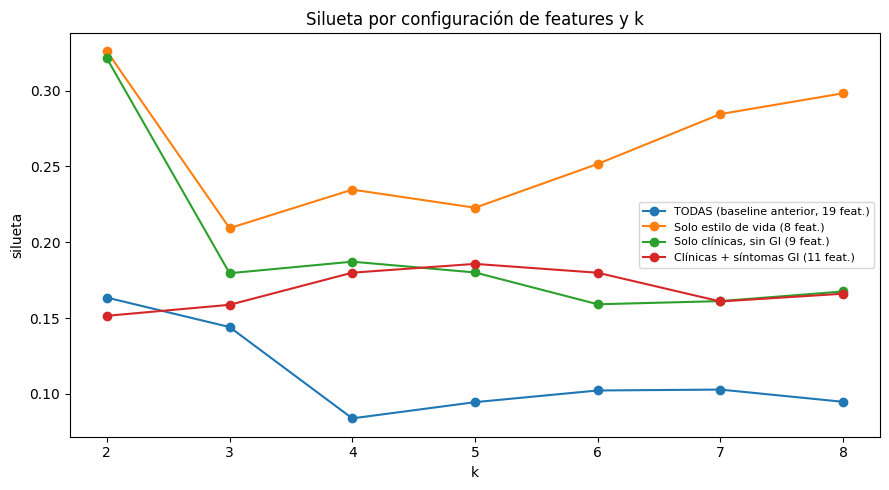

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, res in results.items():
    ax.plot(res['k'], res['silueta'], marker='o', label=name)
ax.set_xlabel('k'); ax.set_ylabel('silueta'); ax.legend(fontsize=8); ax.set_title('Silueta por configuración de features y k')
plt.tight_layout()
plt.show()

## Lectura del sweep

- **TODAS (19 feat., baseline anterior):** silueta máxima ~0.16 (k=2), ~0.14 en k=3 — la elegida por el modelo anterior. Mezclar clínica con estilo de vida diluye la separación, como sugería la matriz de correlación del notebook 02.
- **Solo estilo de vida:** silueta más alta (~0.32 en k=2, ~0.26 en k=5), pero es una segmentación *conductual* (activo/sedentario, estrés), no clínica — cambia el propósito del producto, no solo el número de clusters.
- **Solo clínicas sin GI:** silueta ~0.32 en k=2 (esencialmente "alto riesgo / bajo riesgo" binario), pero no diferencia el *tipo* de riesgo metabólico.
- **Clínicas + síntomas GI (11 feat.):** silueta sube de forma sostenida hasta un máximo local claro en **k=5 (~0.19)**, mejor que el baseline anterior (k=3, ~0.14-0.16) y con clusters clínicamente interpretables (se perfila abajo). Es la configuración elegida.

## Perfilamiento del ganador: clínicas + GI, *k*=5

Como se ve en la tabla de silueta anterior, k=5 (0.1857) es un máximo local claro para esta configuración de features: mejor que k=4 y que k=6-8, y mejor que el mejor resultado del baseline anterior de 19 features (k=2-3, 0.14-0.16).

In [5]:
X = StandardScaler().fit_transform(df[CLINICAL_GI].values)
km5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X)
dfc = df.copy()
dfc['cluster'] = km5.labels_

profile_cols = CLINICAL_GI + ['estres_alto_bin', 'ansioso_bin', 'tecnica_estres_bin', 'hace_actividad']
prof = dfc.groupby('cluster')[profile_cols].mean().round(2)
prof['n'] = dfc['cluster'].value_counts().sort_index()
prof['pct'] = (100 * prof['n'] / len(dfc)).round(1)
prof.T

cluster,0,1,2,3,4
imc,33.33,27.64,29.52,26.16,24.67
perimetro,101.12,90.64,96.47,86.12,81.11
pa_sistolica,120.77,118.86,120.02,117.56,115.60
pa_diastolica,78.53,77.57,78.19,76.38,75.19
colesterol_total,189.49,201.19,176.39,196.38,198.70
colesterol_hdl,43.64,49.19,46.84,51.34,54.46
hba1c,5.51,5.60,6.37,5.52,5.35
usa_hipoglicemiante,0.01,0.00,0.99,0.00,0.00
usa_hipolipemiante,0.02,1.00,0.79,0.00,0.00
n_sintomas_gi,0.29,0.05,0.02,2.09,0.96


## Interpretación clínica de cada cluster

| Cluster (perfil dominante) | ~% | Rasgo distintivo |
|---|---|---|
| **Obesidad** | ~29% | IMC y perímetro abdominal más altos, presión arterial elevada, sin medicación específica |
| **Dislipidemia** | ~14% | ~100% usa hipolipemiantes, colesterol total más alto de los 5 |
| **Glicemia** | ~14% | ~99% usa hipoglicemiantes, HbA1c claramente más alta (prediabetes/diabetes) |
| **Digestivo** | ~10% | Síntomas gastrointestinales frecuentes (2+ en promedio), 100% usa antiácidos/IBP |
| **Bajo riesgo** | ~33% | Los marcadores más bajos en las 11 dimensiones |

**Conclusión frente al modelo anterior:** el antiguo cluster único "Cardiometabólico" (~15% de la población) en realidad son **tres** perfiles clínicamente distintos con vías de intervención distintas — control de peso, manejo de lípidos y control glicémico no son la misma conversación con el paciente. "Digestivo" y "Bajo riesgo" se mantienen como clusters propios, consistente con el hallazgo anterior. Sigue **sin existir un cluster "Mixto" natural** (se confirma también en los sweeps de k=6 a 9: ningún cluster combina síntomas GI con marcadores cardiometabólicos elevados de forma predominante).

## Guardar el resultado del sweep (para el README y trazabilidad)

In [6]:
summary_rows = []
for name, res in results.items():
    best = res.loc[res['silueta'].idxmax()]
    summary_rows.append({'configuracion': name, 'k_optimo': int(best['k']), 'silueta_maxima': round(best['silueta'], 4)})
summary = pd.DataFrame(summary_rows)
summary.to_csv('../data/_processed/03_sweep_summary.csv', index=False)
summary

,configuracion,k_optimo,silueta_maxima
0,"TODAS (baseline anterior, 19 feat.)",2,0.1635
1,Solo estilo de vida (8 feat.),2,0.3260
2,"Solo clínicas, sin GI (9 feat.)",2,0.3213
3,Clínicas + síntomas GI (11 feat.),5,0.1857
